# Calculate Customer Lifetime Value

In [30]:
#Import necessary libraries
import pandas as pd
import matplotlib as plt

#Import Data
tx_data=pd.read_csv("online_retail_II.csv", encoding="cp1252")
tx_data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [31]:
#Check the shape (number of columns and rows) in the dataset
tx_data.shape

(1067371, 8)

In [32]:
#Find out missing values
tx_data.isnull().sum(axis=0)

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [33]:
#Remove time from date
tx_data['InvoiceDate'] = pd.to_datetime(tx_data['InvoiceDate']).dt.date

#There are 135,080 missing values in the CustomerID column, and since our analysis is based on customers, 
#we will remove these missing values.
tx_data = tx_data[pd.notnull(tx_data['Customer ID'])]

#Keep records with non negative quantity
tx_data = tx_data[(tx_data['Quantity']>0)]

#Add a new column depicting total sales
tx_data['Total_Sales'] = tx_data['Quantity'] * tx_data['Price']
necessary_cols = ['Customer ID', 'InvoiceDate', 'Total_Sales']
tx_data = tx_data[necessary_cols]
tx_data.head()

,Customer ID,InvoiceDate,Total_Sales
0,13085.0,2009-12-01,83.4
1,13085.0,2009-12-01,81.0
2,13085.0,2009-12-01,81.0
3,13085.0,2009-12-01,100.8
4,13085.0,2009-12-01,30.0


In [34]:
#Print records pertaining unique Customer IDs
print(tx_data['Customer ID'].nunique())

5881


In [35]:
#Check the Last order date
last_order_date = tx_data['InvoiceDate'].max()
print(last_order_date)
print("--------------------------------------")
print(tx_data[(tx_data['Customer ID']==12346)])

2011-12-09
--------------------------------------
        Customer ID InvoiceDate  Total_Sales
27994       12346.0  2009-12-14        45.00
28251       12346.0  2009-12-14        22.50
28254       12346.0  2009-12-14        22.50
39398       12346.0  2009-12-18        22.50
39411       12346.0  2009-12-18         1.00
45228       12346.0  2010-01-04        22.50
45230       12346.0  2010-01-04        22.50
56117       12346.0  2010-01-14        22.50
66084       12346.0  2010-01-22        22.50
107800      12346.0  2010-03-02         3.25
107801      12346.0  2010-03-02         5.95
107802      12346.0  2010-03-02         5.95
107803      12346.0  2010-03-02         5.95
107804      12346.0  2010-03-02         5.95
253028      12346.0  2010-06-28         7.49
253029      12346.0  2010-06-28         7.49
253030      12346.0  2010-06-28         7.49
253031      12346.0  2010-06-28         7.49
253032      12346.0  2010-06-28         7.49
253033      12346.0  2010-06-28         7.49
25303

In [36]:
from lifetimes.plotting import *
from lifetimes.utils import *
#Built-in utility functions from lifetimes package to transform the transactional data (one row per purchase) 
#into summary data (a frequency, recency, age and monetary).

lf_tx_data = summary_data_from_transaction_data(tx_data, 'Customer ID', 'InvoiceDate', monetary_value_col='Total_Sales', observation_period_end='2011-12-9')
lf_tx_data.reset_index().head()

,Customer ID,frequency,recency,T,monetary_value
0,12346.0,7.0,400.0,725.0,11066.637143
1,12347.0,7.0,402.0,404.0,717.398571
2,12348.0,4.0,363.0,438.0,449.310000
3,12349.0,3.0,571.0,589.0,1120.056667
4,12350.0,0.0,0.0,310.0,0.000000


count    5881.000000
mean        4.630335
std        10.001176
min         0.000000
25%         0.000000
50%         2.000000
75%         5.000000
max       254.000000
Name: frequency, dtype: float64
---------------------------------------
Percentage of customers purchase the item only once: 28.77 %


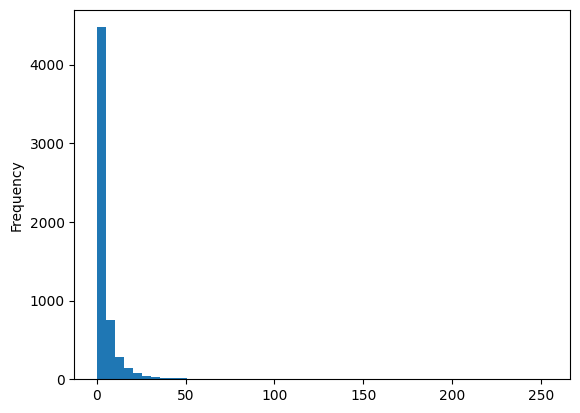

In [37]:
%matplotlib inline
#Create histogram to find out how many customers purchased item only once.
lf_tx_data['frequency'].plot(kind='hist', bins=50)
print(lf_tx_data['frequency'].describe())
print("---------------------------------------")
one_time_buyers = round(sum(lf_tx_data['frequency'] == 0)/float(len(lf_tx_data))*(100),2)
print("Percentage of customers purchase the item only once:", one_time_buyers ,"%")

In [38]:
#Frequency/Recency Analysis Using the BG/NBD Model
from lifetimes import BetaGeoFitter
bgf = BetaGeoFitter(penalizer_coef=0.0)
bgf.fit(lf_tx_data['frequency'], lf_tx_data['recency'], lf_tx_data['T'])
print(bgf)

<lifetimes.BetaGeoFitter: fitted with 5881 subjects, a: 0.11, alpha: 63.18, b: 2.42, r: 0.66>


In [39]:
#count the number of unique customers in the dataset
tx_data['Customer ID'].nunique()

5881

In [40]:
bgf.summary

,coef,se(coef),lower 95% bound,upper 95% bound
r,0.662732,0.015825,0.631715,0.693749
alpha,63.184460,1.934702,59.392443,66.976476
a,0.108660,0.015446,0.078387,0.138934
b,2.418366,0.524988,1.389391,3.447342


<Axes: title={'center': 'Expected Number of Future Purchases for 1 Unit of Time,\nby Frequency and Recency of a Customer'}, xlabel="Customer's Historical Frequency", ylabel="Customer's Recency">

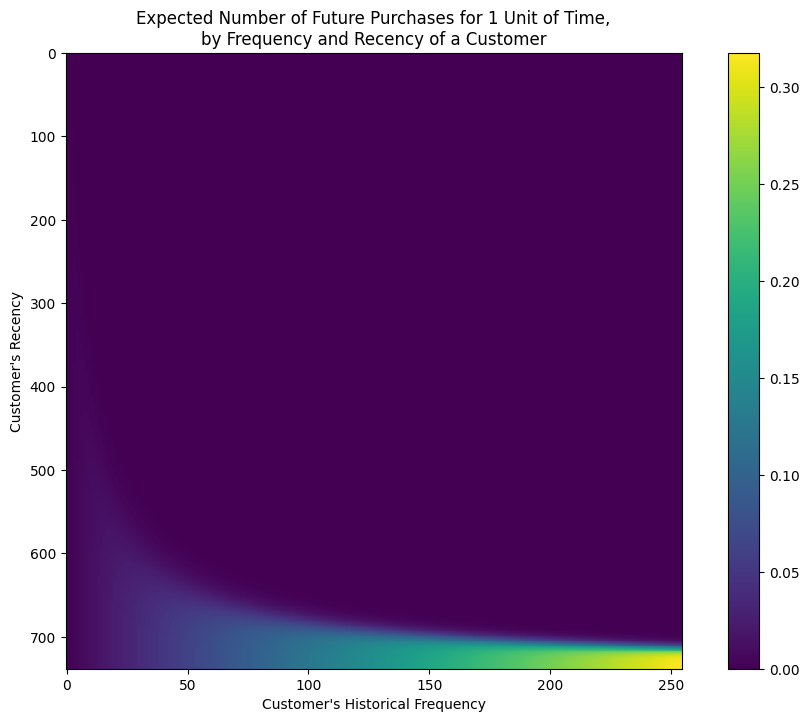

In [41]:
#Visualizing our frequency/recency matrix
%matplotlib inline
import matplotlib.pyplot as plt
from lifetimes.plotting import plot_frequency_recency_matrix
fig = plt.figure(figsize=(12,8))
plot_frequency_recency_matrix(bgf)

<Axes: title={'center': 'Probability Customer is Alive,\nby Frequency and Recency of a Customer'}, xlabel="Customer's Historical Frequency", ylabel="Customer's Recency">

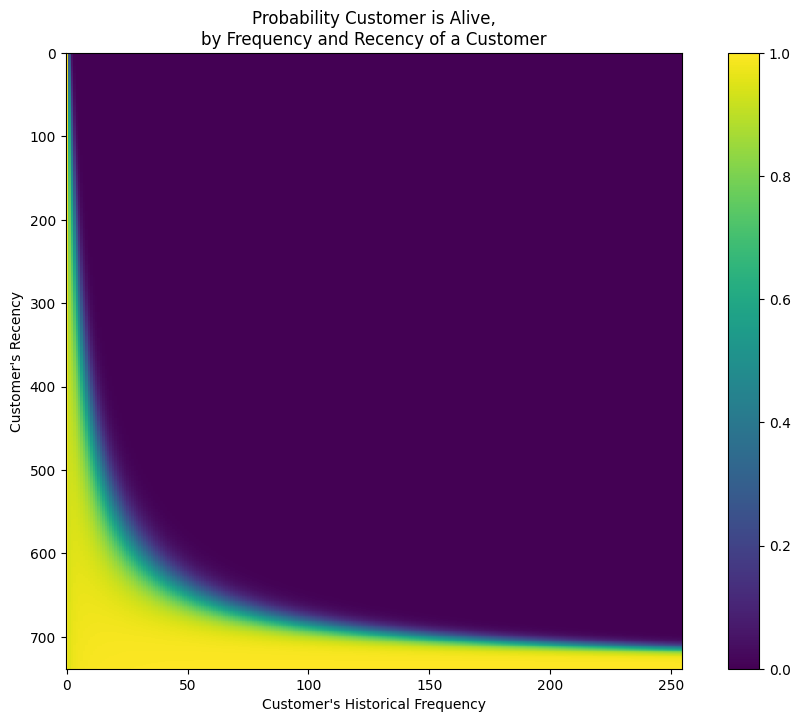

In [42]:
#predict if the customers are surely alive:
from lifetimes.plotting import plot_probability_alive_matrix
fig = plt.figure(figsize=(12,8))
plot_probability_alive_matrix(bgf)

In [43]:
#Predict future transaction in next 10 days i.e.top 10 customers that the model expects them to make purchases 
#in the next 10 days, based on historical data

# t=730
t = 10
lf_tx_data['pred_num_txn'] = round(bgf.conditional_expected_number_of_purchases_up_to_time(t, lf_tx_data['frequency'], lf_tx_data['recency'], lf_tx_data['T']),2)
lf_tx_data.sort_values(by='pred_num_txn', ascending=False).head(10).reset_index()

,Customer ID,frequency,recency,T,monetary_value,pred_num_txn
0,14911.0,254.0,737.0,738.0,1162.358268,3.17
1,12748.0,202.0,735.0,735.0,279.101436,2.54
2,15311.0,195.0,738.0,738.0,594.605846,2.44
3,17841.0,192.0,736.0,737.0,366.423490,2.40
4,14606.0,180.0,735.0,736.0,170.255889,2.26
5,13089.0,131.0,735.0,737.0,888.318779,1.64
6,14527.0,120.0,735.0,737.0,223.904250,1.51
7,14156.0,120.0,729.0,738.0,2607.329750,1.50
8,12971.0,98.0,721.0,724.0,162.360612,1.25
9,13798.0,98.0,730.0,731.0,768.906837,1.24


<Axes: title={'center': 'Frequency of Repeat Transactions'}, xlabel='Number of Calibration Period Transactions', ylabel='Customers'>

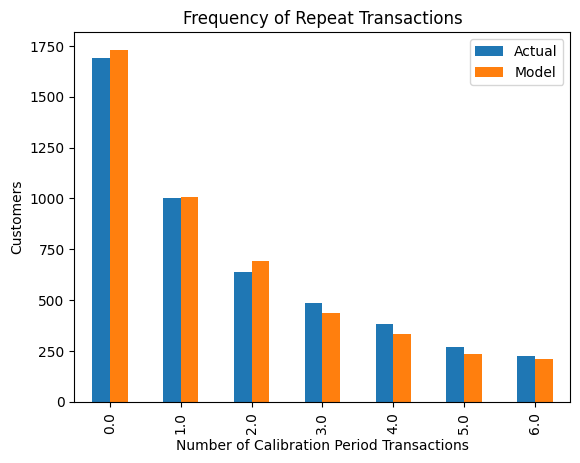

In [44]:
#Assessing model fit
from lifetimes.plotting import plot_period_transactions
plot_period_transactions(bgf)

In [45]:
#Customer's future transaction prediction for next 10 days

t = 10
individual = lf_tx_data.loc[14911]
bgf.predict(t, individual['frequency'], individual['recency'], individual['T'])

#OBSERVATION: Our model predicts that customer 14911’s future transaction is appx 3 in 10 days.

np.float64(3.1745833898772493)

In [46]:
#Check if there is correlation between monetary value and frequency in order to use gamma gamma model for CLV calculation.
lf_tx_data[['monetary_value', 'frequency']].corr()

,monetary_value,frequency
monetary_value,1.00000,0.04854
frequency,0.04854,1.00000


In [47]:
# lf_tx_data['Customer ID'].nunique()
lf_tx_data.columns

Index(['frequency', 'recency', 'T', 'monetary_value', 'pred_num_txn'], dtype='object')

In [48]:
#Shortlist customers who had at least one repeat purchase with the company. 
shortlisted_customers = lf_tx_data[lf_tx_data['frequency']>0]
print(shortlisted_customers.head().reset_index())
print("-----------------------------------------")
print("The Number of Returning Customers are: ",len(shortlisted_customers))

   Customer ID  frequency  recency      T  monetary_value  pred_num_txn
0      12346.0        7.0    400.0  725.0    11066.637143          0.06
1      12347.0        7.0    402.0  404.0      717.398571          0.16
2      12348.0        4.0    363.0  438.0      449.310000          0.09
3      12349.0        3.0    571.0  589.0     1120.056667          0.05
4      12352.0        8.0    356.0  392.0      338.261250          0.19
-----------------------------------------
The Number of Returning Customers are:  4189


In [49]:
#Train gamma-gamma model by taking into account the monetary_value.
from lifetimes import GammaGammaFitter
ggf = GammaGammaFitter(penalizer_coef = 0)
ggf.fit(shortlisted_customers['frequency'],
        shortlisted_customers['monetary_value'])
print(ggf)

<lifetimes.GammaGammaFitter: fitted with 4189 subjects, p: 2.13, q: 3.53, v: 486.53>


In [51]:
ggf.summary

,coef,se(coef),lower 95% bound,upper 95% bound
p,2.130608,0.104812,1.925176,2.336040
q,3.530916,0.112395,3.310621,3.751210
v,486.532804,37.150445,413.717931,559.347677


In [52]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict monetary values using the Gamma-Gamma model
shortlisted_customers['predicted_monetary_value'] = ggf.conditional_expected_average_profit(
    shortlisted_customers['frequency'],
    shortlisted_customers['monetary_value']
)

# Actual vs predicted
y_true = shortlisted_customers['monetary_value']
y_pred = shortlisted_customers['predicted_monetary_value']

# Compute metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R² Score: {r2:.2f}")


RMSE: 1428.33
MAE: 91.18
R² Score: 0.71


In [53]:
#After applying Gamma-Gamma model, now we can estimate average transaction value for each customer. 
print(ggf.conditional_expected_average_profit(
        lf_tx_data['frequency'],
        lf_tx_data['monetary_value']
    ).head(10))

Customer ID
12346.0    9520.529482
12347.0     672.740683
12348.0     440.212758
12349.0     918.531323
12350.0     409.579325
12351.0     409.579325
12352.0     347.481829
12353.0     263.054511
12354.0     409.579325
12355.0     432.350492
dtype: float64


In [54]:
lf_tx_data['pred_txn_value'] = round(ggf.conditional_expected_average_profit(
        lf_tx_data['frequency'],
        lf_tx_data['monetary_value']), 2)
lf_tx_data.reset_index().head()

,Customer ID,frequency,recency,T,monetary_value,pred_num_txn,pred_txn_value
0,12346.0,7.0,400.0,725.0,11066.637143,0.06,9520.53
1,12347.0,7.0,402.0,404.0,717.398571,0.16,672.74
2,12348.0,4.0,363.0,438.0,449.310000,0.09,440.21
3,12349.0,3.0,571.0,589.0,1120.056667,0.05,918.53
4,12350.0,0.0,0.0,310.0,0.000000,0.02,409.58


In [55]:
#Calculate Customer Lifetime Value
lf_tx_data['CLV'] = round(ggf.customer_lifetime_value(
    bgf, #the model to use to predict the number of future transactions
    lf_tx_data['frequency'],
    lf_tx_data['recency'],
    lf_tx_data['T'],
    lf_tx_data['monetary_value'],
    time=12, # months
    # discount_rate=0.01 # monthly discount rate ~ 12.7% annually
), 2)

# lf_tx_data.drop(lf_tx_data.iloc[:, 0:6], inplace=True, axis=1)

lf_tx_data.sort_values(by='CLV', ascending=False).head(10).reset_index()

,Customer ID,frequency,recency,T,monetary_value,pred_num_txn,pred_txn_value,CLV
0,18102.0,66.0,738.0,738.0,9189.930455,0.83,9034.69,248222.33
1,14646.0,90.0,736.0,737.0,5809.905333,1.13,5739.56,214772.72
2,16446.0,1.0,205.0,205.0,168469.600000,0.06,77223.53,148507.83
3,17450.0,30.0,430.0,438.0,6924.523000,0.61,6676.38,133004.86
4,14156.0,120.0,729.0,738.0,2607.329750,1.50,2585.79,128336.00
5,14911.0,254.0,737.0,738.0,1162.358268,3.17,1158.85,121733.34
6,14096.0,16.0,97.0,101.0,4071.434375,1.00,3818.36,120766.87
7,13694.0,82.0,732.0,735.0,2365.279512,1.03,2337.35,79907.26
8,12415.0,22.0,503.0,527.0,6460.528636,0.38,6150.55,76750.04
9,17511.0,50.0,735.0,737.0,3449.898200,0.63,3379.34,70597.22


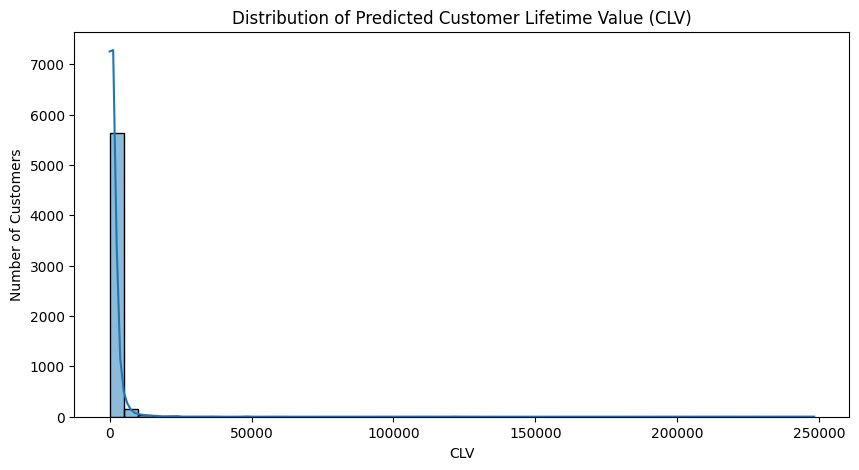

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.histplot(lf_tx_data['CLV'], kde=True, bins=50)
plt.title('Distribution of Predicted Customer Lifetime Value (CLV)')
plt.xlabel('CLV')
plt.ylabel('Number of Customers')
plt.show()


In [57]:
# Segment CLV into 3 categories
lf_tx_data['CLV_Segment'] = pd.qcut(
    lf_tx_data['CLV'], 
    q=3, 
    labels=['Low', 'Medium', 'High']
)

# Display updated table
# lf_tx_data.sort_values(by='CLV', ascending=False).head(10).reset_index()
lf_tx_data.head(15)


,frequency,recency,T,monetary_value,pred_num_txn,pred_txn_value,CLV,CLV_Segment
Customer ID,,,,,,,,
12346.0,7.0,400.0,725.0,11066.637143,0.06,9520.53,17428.70,High
12347.0,7.0,402.0,404.0,717.398571,0.16,672.74,3565.72,High
12348.0,4.0,363.0,438.0,449.310000,0.09,440.21,1289.95,High
12349.0,3.0,571.0,589.0,1120.056667,0.05,918.53,1659.46,High
12350.0,0.0,0.0,310.0,0.000000,0.02,409.58,238.90,Low
12351.0,0.0,0.0,375.0,0.000000,0.02,409.58,204.17,Low
12352.0,8.0,356.0,392.0,338.261250,0.19,347.48,2113.71,High
12353.0,1.0,204.0,408.0,89.000000,0.03,263.05,273.85,Low
12354.0,0.0,0.0,232.0,0.000000,0.02,409.58,300.25,Low
